In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '..')

df = pd.read_csv('../results/raw/results.csv')
print(f"Total runs: {len(df)}")
print(f"Models: {df['model'].unique()}")
print(f"Datasets: {df['dataset'].unique()}")
df.head()

Total runs: 2000
Models: ['XGBoost' 'LightGBM' 'CatBoost' 'RandomForest']
Datasets: ['MI' 'BreastCancer']


,dataset,fold,train_size,model,auroc,auprc,brier,train_time,inf_time
0,MI,0,50,XGBoost,0.929406,0.836188,0.077087,0.557120,0.000008
1,MI,0,50,LightGBM,0.712338,0.345315,0.150641,0.064567,0.000003
2,MI,0,50,CatBoost,0.926716,0.868663,0.075818,0.362727,0.000005
3,MI,0,50,RandomForest,0.935111,0.879442,0.075212,0.405676,0.000297
4,MI,0,100,XGBoost,0.933673,0.866524,0.068687,0.092353,0.000007


In [7]:
print('=== By Training Size (MI only) ===')
mi = df[df['dataset']=='MI']
print(mi.groupby(['train_size','model'])['auroc'].mean().round(3).unstack())

print('\n=== By Training Size (BreastCancer only) ===')
bc = df[df['dataset']=='BreastCancer']
print(bc.groupby(['train_size','model'])['auroc'].mean().round(3).unstack())

print('\n=== By Dataset (overall) ===')
print(df.groupby(['dataset','model'])['auroc'].mean().round(3).unstack())

=== By Training Size (MI only) ===
model       CatBoost  LightGBM  RandomForest  XGBoost
train_size                                           
50             0.919     0.646         0.935    0.885
100            0.925     0.761         0.937    0.926
200            0.927     0.922         0.937    0.931
500            0.941     0.937         0.942    0.949
1002           0.951     0.955         0.950    0.957
1003           0.944     0.946         0.945    0.951

=== By Training Size (BreastCancer only) ===
model       CatBoost  LightGBM  RandomForest  XGBoost
train_size                                           
50             0.983     0.981         0.985    0.978
100            0.986     0.985         0.988    0.985
200            0.991     0.991         0.990    0.989
455            0.994     0.994         0.991    0.994
456            0.993     0.994         0.989    0.992

=== By Dataset (overall) ===
model         CatBoost  LightGBM  RandomForest  XGBoost
dataset                

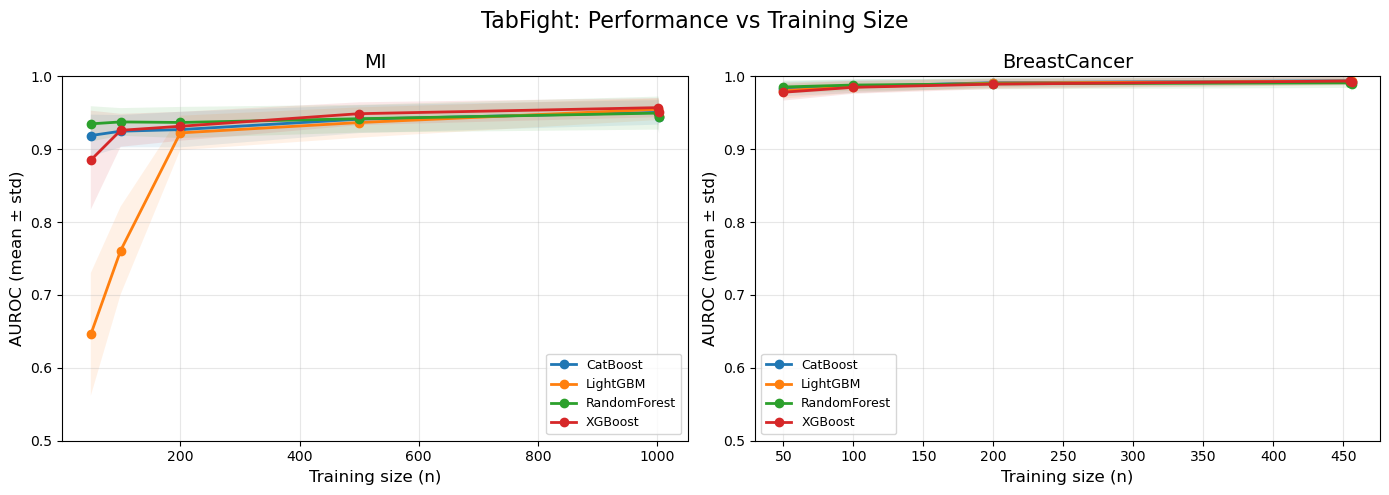

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset in zip(axes, ['MI', 'BreastCancer']):
    data = df[df['dataset'] == dataset]
    summary = data.groupby(['model', 'train_size']).agg(
        auroc_mean=('auroc', 'mean'),
        auroc_std=('auroc', 'std')
    ).reset_index()

    for model, group in summary.groupby('model'):
        group = group.sort_values('train_size')
        ax.plot(group['train_size'], group['auroc_mean'],
                marker='o', label=model, linewidth=2)
        ax.fill_between(
            group['train_size'],
            group['auroc_mean'] - group['auroc_std'],
            group['auroc_mean'] + group['auroc_std'],
            alpha=0.1
        )

    ax.set_xlabel('Training size (n)', fontsize=12)
    ax.set_ylabel('AUROC (mean ± std)', fontsize=12)
    ax.set_title(f'{dataset}', fontsize=14)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.5, 1.0)

plt.suptitle('TabFight: Performance vs Training Size', fontsize=16)
plt.tight_layout()
plt.savefig('../results/figures/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

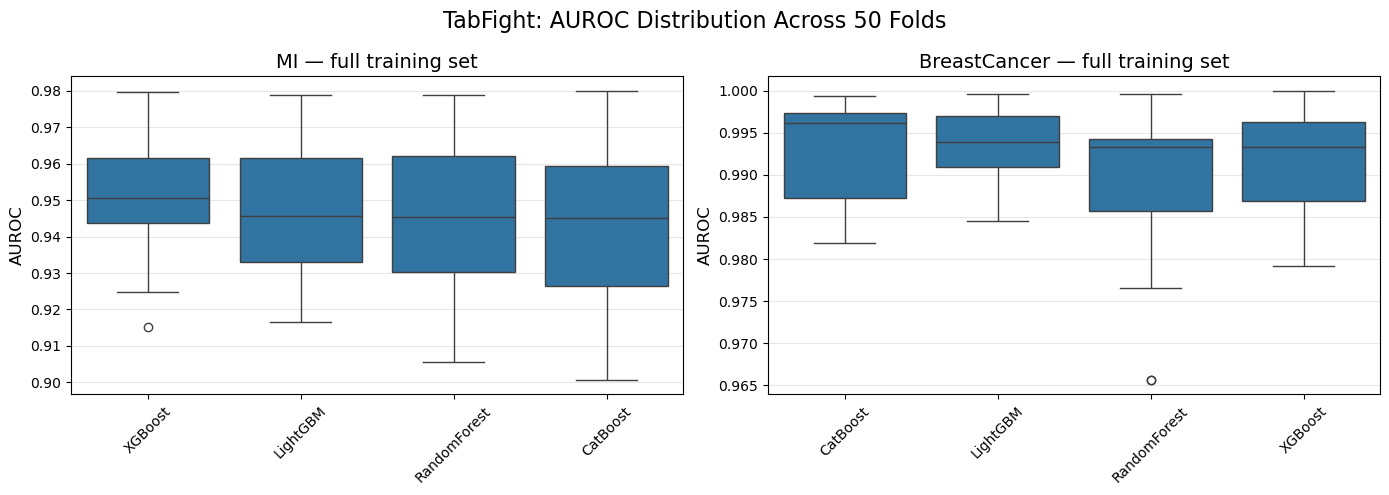

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset in zip(axes, ['MI', 'BreastCancer']):
    # use full training size only
    full_size = df[df['dataset'] == dataset]['train_size'].max()
    data = df[(df['dataset'] == dataset) & (df['train_size'] == full_size)]

    order = (data.groupby('model')['auroc']
             .median()
             .sort_values(ascending=False)
             .index)

    sns.boxplot(data=data, x='model', y='auroc', order=order, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('AUROC', fontsize=12)
    ax.set_title(f'{dataset} — full training set', fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('TabFight: AUROC Distribution Across 50 Folds', fontsize=16)
plt.tight_layout()
plt.savefig('../results/figures/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
full_sizes = df.groupby('dataset')['train_size'].max().to_dict()

rows = []
for dataset, full_size in full_sizes.items():
    data = df[(df['dataset'] == dataset) & (df['train_size'] == full_size)]
    summary = data.groupby('model').agg(
        auroc_mean=('auroc', 'mean'),
        auroc_std=('auroc', 'std'),
        auprc_mean=('auprc', 'mean'),
        brier_mean=('brier', 'mean'),
        train_time=('train_time', 'mean'),
    ).reset_index()
    summary['dataset'] = dataset
    rows.append(summary)

table = pd.concat(rows)
table['AUROC'] = table.apply(lambda r: f"{r['auroc_mean']:.3f} ± {r['auroc_std']:.3f}", axis=1)
table['AUPRC'] = table['auprc_mean'].round(3)
table['Brier'] = table['brier_mean'].round(3)
table['Time(s)'] = table['train_time'].round(2)

print(table[['dataset', 'model', 'AUROC', 'AUPRC', 'Brier', 'Time(s)']].to_string(index=False))

     dataset        model         AUROC  AUPRC  Brier  Time(s)
BreastCancer     CatBoost 0.993 ± 0.006  0.991  0.029     0.54
BreastCancer     LightGBM 0.994 ± 0.004  0.991  0.026     0.07
BreastCancer RandomForest 0.989 ± 0.010  0.986  0.036     0.41
BreastCancer      XGBoost 0.992 ± 0.006  0.989  0.028     0.15
          MI     CatBoost 0.944 ± 0.022  0.883  0.062     0.35
          MI     LightGBM 0.946 ± 0.021  0.888  0.061     0.08
          MI RandomForest 0.945 ± 0.023  0.883  0.062     0.47
          MI      XGBoost 0.951 ± 0.017  0.890  0.061     0.13


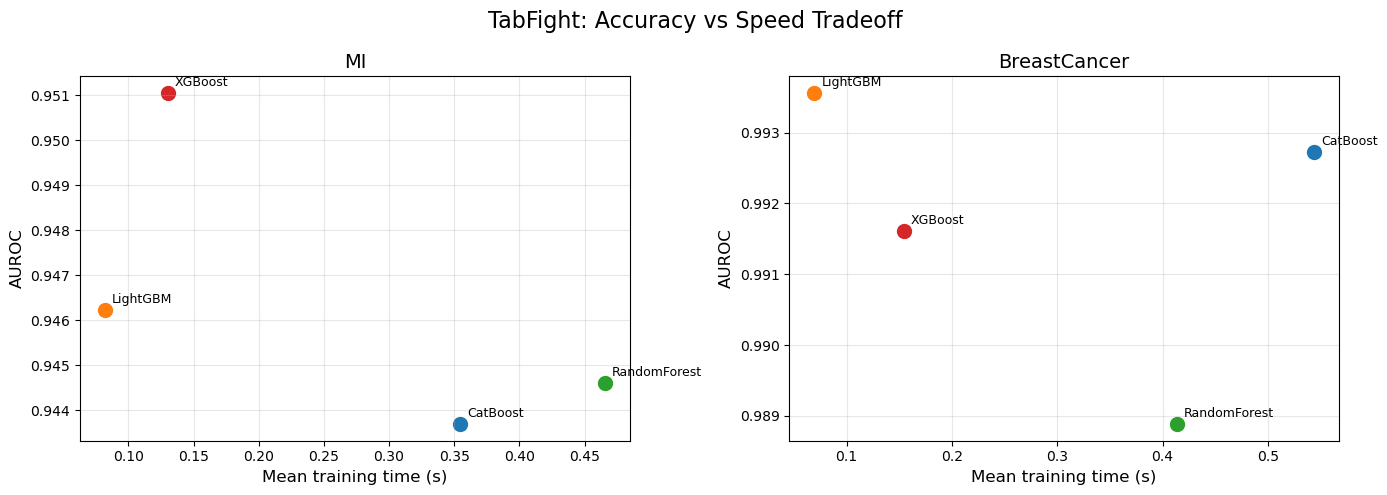

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset in zip(axes, ['MI', 'BreastCancer']):
    full_size = df[df['dataset'] == dataset]['train_size'].max()
    data = df[(df['dataset'] == dataset) & (df['train_size'] == full_size)]
    summary = data.groupby('model').agg(
        auroc_mean=('auroc', 'mean'),
        train_time_mean=('train_time', 'mean')
    ).reset_index()

    for _, row in summary.iterrows():
        ax.scatter(row['train_time_mean'], row['auroc_mean'], s=100)
        ax.annotate(row['model'],
                   (row['train_time_mean'], row['auroc_mean']),
                   textcoords='offset points', xytext=(5, 5), fontsize=9)

    ax.set_xlabel('Mean training time (s)', fontsize=12)
    ax.set_ylabel('AUROC', fontsize=12)
    ax.set_title(f'{dataset}', fontsize=14)
    ax.grid(True, alpha=0.3)

plt.suptitle('TabFight: Accuracy vs Speed Tradeoff', fontsize=16)
plt.tight_layout()
plt.savefig('../results/figures/efficiency.png', dpi=150, bbox_inches='tight')
plt.show()